# Next Carwash Station
Where is the optimal geographical location in Calgary, Alberta, to open a new car wash business to maximize demand and profits?

I will use Machine Learning techniques that I have learned to apply it to this real world example.

### Why is the Question Important:

Solving this question helps understand and perfect my skills using ML to reduces the financial risk of a decision where to open a new business. Its combing theory with practical application of ML in the real world with real effects of if a venture will be profitable or a failed one.

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

## Data:

I researched online how Starbucks used AI/ML to expand into Hyderabad. I found they used The Atlas Program which is the "secret sauce" of how Starbucks determines where to open stores. Its a system that relies on Esri for geo-spatial data along with analytics to finalize store location. Data they look at:
- traffic patterns
- population density
- income levels / demographics
- nearby competitor presence
- proximity to other Starbucks locations

#### Dataset I Can Use -- 
Kaggle has one dataset that has car wash performance and spending, but doesnt seem like its useable. Another kaggle dataset has great info about location of carwashes but again nothing much to use.  
* Kaggle car wash performance -- https://www.kaggle.com/datasets/blackmamba2024/car-wash-statistics
* Kaggle car wash location -- https://www.kaggle.com/datasets/romankhrustalev/usa-car-wash-businesses-dataset

I could not find any useful car wash data sets on UCI, OpenML, and Google Dataset Search.

#### Dataset Generation --
I will use AI tools to generate car wash data that would be similar to real world data that the Atlas Program uses (data mentioned above)

#### Calgary Traffic Patterns
Key variables that would be in the City of Calgary’s Open Data Portal. Key variables include:
- AADT_Volume (Average Annual Daily Traffic): This is the primary driver of demand. Higher volumes generally indicate higher "impulse" wash potential.
- Road_Class: Helps distinguish between high-speed expressways (where people might not stop) and major collectors (where retail businesses like car washes thrive).
- Commercial_Activity_Score: A engineered feature (1–10) representing the density of nearby retail or industrial hubs.
- Truck_Volume_Pct: Critical for determining if a location should focus on standard passenger vehicles or high-clearance/wand-wash bays for work trucks.
- Distance_to_City_Center_km: Useful for seeing if demand is centralized or shifting toward the suburbs (Stoney Trail areas).

In [6]:
demand_df = pd.read_csv('data/calgary_traffic_patterns.csv')
print(f"Demand Data: {demand_df.shape}")
demand_df.head()

Demand Data: (70, 11)


,Location_ID,Street_Intersection,Quadrant,Latitude,Longitude,AADT_Volume,Road_Class,Commercial_Activity_Score,Truck_Volume_Pct,Distance_to_City_Center_km,Nearby_Industrial_Zone
0,CAL-TRAF-001,Deerfoot Trail & 17 Ave SE,SE,51.206957,-113.988382,70795,Expressway/Arterial,7,11.5,20.26,No
1,CAL-TRAF-002,Macleod Trail & Heritage Dr SW,SW,51.030030,-114.131765,92194,Expressway/Arterial,10,13.3,6.84,Yes
2,CAL-TRAF-003,Crowchild Trail & 24 Ave NW,NW,51.124620,-113.914021,55769,Expressway/Arterial,4,4.9,19.64,Yes
3,CAL-TRAF-004,Stoney Trail & Country Hills Blvd NW,NW,51.084895,-114.249356,108707,Expressway/Arterial,3,6.7,20.20,No
4,CAL-TRAF-005,16 Ave NE & 36 St NE,NE,50.881500,-113.901348,39233,Major Collector,9,9.3,26.20,No


#### Calgary Car Wash Competition
A look at market supply in the region. Key variables include:
- Wash_Type: Crucial for identifying market gaps. If an area has 5 "Automatic Touchless" washes but 0 "Wand Washes," there might be an opportunity for the latter.
- Customer_Rating: Can be used to find "Weak Competition." A cluster of car washes with low ratings (e.g., < 3.5) represents a location where a high-quality new entrant could easily steal market share.
- Number_of_Bays: Indicates the capacity of the competitor.
- Price_Level: Helps you determine the "premium" vs "value" positioning of specific neighborhoods.

In [12]:
competition_df = pd.read_csv('data/calgary_car_wash_competition.csv')
print(f"Competition Data: {competition_df.shape}")
competition_df.head()

Competition Data: (85, 10)


,Business_ID,Brand_Name,Wash_Type,Quadrant,Latitude,Longitude,Customer_Rating,Number_of_Bays,Price_Level,24_Hour_Access
0,COMP-001,Mint Smartwash,Wand Wash,SW,51.175218,-114.023126,4.2,6,$$,No
1,COMP-002,Co-op,Automatic Touchless,SW,50.938931,-114.033220,2.9,1,$,No
2,COMP-003,Petro-Canada,Automatic Touchless,NW,51.198588,-114.228132,2.9,2,$,No
3,COMP-004,Independent,Automatic Touchless,SW,50.939800,-114.120774,3.2,2,$,No
4,COMP-005,Petro-Canada,Full Service Detailing,NW,51.014507,-114.047441,4.1,2,$$,Yes


#### Calgary Demographics 
Demographic data needed to predict where high-value customers live. Key variables include:
- Median_Household_Income: Important for "Full Service Detailing" or "Premium Touchless" business models.
- Pct_Apartment_Dwellers: A critical variable for car washes. People living in high-rise apartments or condos (like in the Beltline) generally do not have access to a driveway or hose, making them "captive" customers for commercial car washes.
- Avg_Cars_Per_Household: Directly proportional to the total addressable market in that neighborhood.
- Population_Density: Helps you identify if a car wash should be a high-volume express model (high density) or a more specialized local shop.

In [9]:
demographic_df = pd.read_csv('data/calgary_demographic.csv')
print(f"Demographic Data: {demographic_df.shape}")
demographic_df.head()

Demographic Data: (100, 13)


,Community_ID,Community_Name,Quadrant,Latitude,Longitude,Median_Household_Income,Population_Density,Pct_Apartment_Dwellers,Pct_Single_Family_Detached,Avg_Cars_Per_Household,Avg_Household_Size,Avg_Household_Age,Population_Total
0,DEMO-001,Beltline,NW,51.124814,-113.952399,160072,6688,74,26,0.5,3.75,43.6,17273
1,DEMO-002,Bridgeland,NW,51.171247,-114.114721,68436,6835,7,93,2.0,2.47,44.6,18371
2,DEMO-003,Panorama Hills,SW,50.984104,-114.026025,169374,8385,67,33,0.6,3.43,50.4,24299
3,DEMO-004,Evergreen,SW,51.096840,-114.217635,109925,4200,58,42,0.7,2.88,30.4,16997
4,DEMO-005,Saddle Ridge,SW,50.985931,-114.204580,146284,8745,16,84,1.9,3.08,49.6,20856


## Techniques:
I will use different ML models to determine which feature set is the most promising.

Possibly use K-Means Clustering to group existing competitors and identify gaps where customer density is high but service density is low.

Possibly use Random Forest with revenue data, to predict the "Success Score" of any given GPS coordinate.

## Expected Results:

The output should be an understanding of where in Calgary represent high-potential locations. I would create a ranked list of the top specific neighborhoods/streets/areas based on success score, high traffic, high income, and low competition where to open a new car wash.

# Analysis

## Data Exploration
Will explore the 3 data sets (Traffic/Demand, Competition, Demographic) to better understand the data variables and the relationships between them.

I want to understand:
* where are the highest demand locations
* which high demand locations do not have any existing competition
* which locations will have high earning population where competition is less


### Traffic Patterns (Demand Data)

Check for any missing values (NaNs). In a real-world scenario, missing traffic counts are common and must be handled.

In [15]:
demand_df.info()
demand_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 70 entries, 0 to 69
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Location_ID                 70 non-null     str    
 1   Street_Intersection         70 non-null     str    
 2   Quadrant                    70 non-null     str    
 3   Latitude                    70 non-null     float64
 4   Longitude                   70 non-null     float64
 5   AADT_Volume                 70 non-null     int64  
 6   Road_Class                  70 non-null     str    
 7   Commercial_Activity_Score   70 non-null     int64  
 8   Truck_Volume_Pct            70 non-null     float64
 9   Distance_to_City_Center_km  70 non-null     float64
 10  Nearby_Industrial_Zone      70 non-null     str    
dtypes: float64(4), int64(2), str(5)
memory usage: 6.1 KB


,Latitude,Longitude,AADT_Volume,Commercial_Activity_Score,Truck_Volume_Pct,Distance_to_City_Center_km
count,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000
mean,51.048843,-114.071362,76255.600000,6.571429,10.800000,15.489000
std,0.108034,0.104616,33303.222711,2.368706,4.307156,5.957137
min,50.870210,-114.249356,15663.000000,3.000000,2.100000,0.750000
25%,50.961913,-114.159746,55962.250000,4.000000,7.925000,11.700000
50%,51.060043,-114.064670,82606.500000,7.000000,10.750000,15.255000
75%,51.132002,-113.988413,104669.500000,8.000000,14.975000,19.202500
max,51.214542,-113.901348,122435.000000,10.000000,17.900000,26.400000


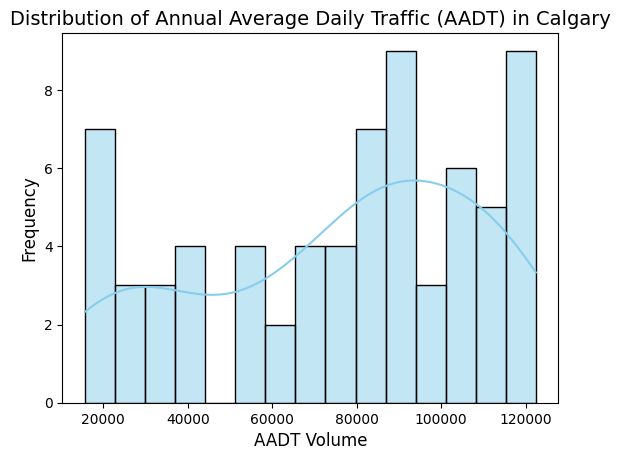

In [27]:
# Histogram of AADT_Volume to see the spread of traffic
#

sns.histplot(demand_df['AADT_Volume'], bins=15, kde=True, color='skyblue')
plt.title('Distribution of Annual Average Daily Traffic (AADT) in Calgary', fontsize=14)
plt.xlabel('AADT Volume', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()
plt.close()

The histogram shows how traffic is spread across the 70 locations. There is a distribution peak at 90,000 and another peak at 120,000. These peaks are for for high-volume expressways (like Deerfoot Trail) and another for busy community arterial roads.

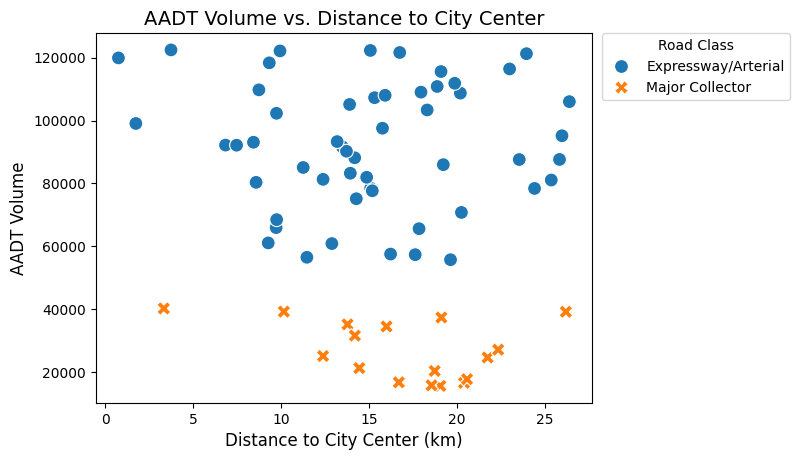

In [30]:
# Scatter Plot: Distance to City Center vs AADT Volume
# 

sns.scatterplot(data=demand_df, x='Distance_to_City_Center_km', y='AADT_Volume', hue='Road_Class', style='Road_Class', s=100)
plt.title('AADT Volume vs. Distance to City Center', fontsize=14)
plt.xlabel('Distance to City Center (km)', fontsize=12)
plt.ylabel('AADT Volume', fontsize=12)
plt.legend(title='Road Class', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.show()
plt.close()

This scatter plot tests the hypothesis: "Does traffic decrease as we move away from the city center?" In Calgary, there actually can be higher traffic clusters far from the center due to the Stoney Trail ring road, which is vital for site selection.

You can see the grouping of Major Collectors and Expressways in the 10 to 20 km distance.

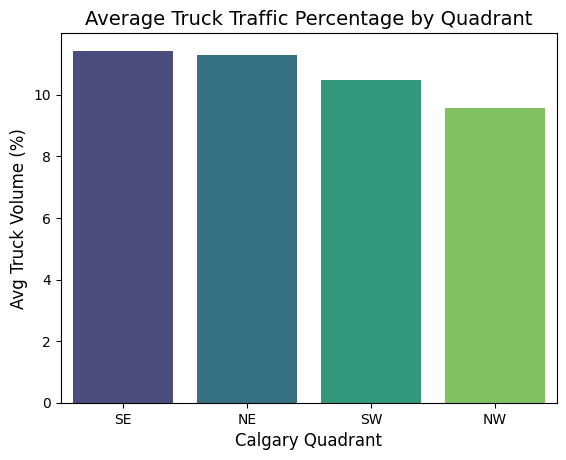

In [26]:
# Grouped Analysis: Average Truck_Volume_Pct across Quadrants
#

avg_truck_pct = demand_df.groupby('Quadrant')['Truck_Volume_Pct'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=avg_truck_pct, x='Quadrant', y='Truck_Volume_Pct', hue='Quadrant', palette='viridis')
plt.title('Average Truck Traffic Percentage by Quadrant', fontsize=14)
plt.xlabel('Calgary Quadrant', fontsize=12)
plt.ylabel('Avg Truck Volume (%)', fontsize=12)
plt.show()
plt.close()

By comparing truck volume, "industrial heavy" regions can be identified. The Southeast shows higher truck percentages, that quadrant is ideal candidate for a Heavy-Duty Wand Wash rather than a luxury detailing shop. Likewise Northwest might be ideal for self serve car washs. 

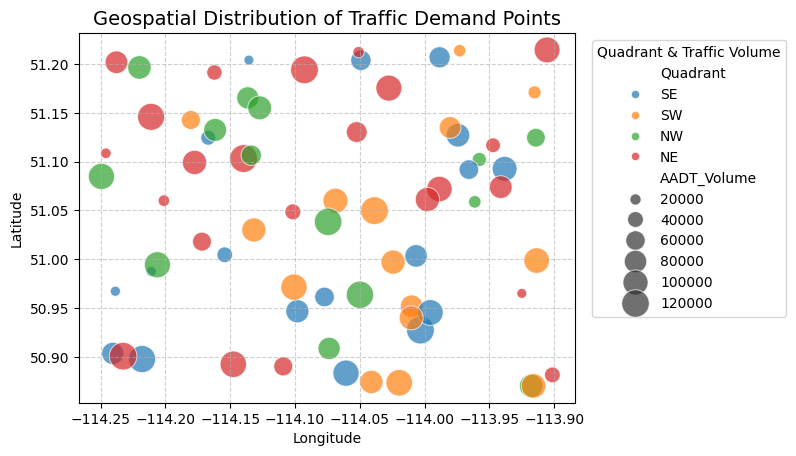

In [31]:
# Geospatial Visualization: Scatter Plot of Latitude/Longitude
#

sns.scatterplot(data=demand_df, x='Longitude', y='Latitude', hue='Quadrant', size='AADT_Volume', sizes=(50, 400), alpha=0.7)
plt.title('Geospatial Distribution of Traffic Demand Points', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Quadrant & Traffic Volume')
plt.show()
plt.close()

This plot is a simplified map of Calgary. The size of the bubbles represents the traffic volume. 

When combining with compeition plot will need to look for large bubbles that do not overlap with existing competition locations.

### Competition Data

In [13]:
competition_df.info()
competition_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Business_ID      85 non-null     str    
 1   Brand_Name       85 non-null     str    
 2   Wash_Type        85 non-null     str    
 3   Quadrant         85 non-null     str    
 4   Latitude         85 non-null     float64
 5   Longitude        85 non-null     float64
 6   Customer_Rating  85 non-null     float64
 7   Number_of_Bays   85 non-null     int64  
 8   Price_Level      85 non-null     str    
 9   24_Hour_Access   85 non-null     str    
dtypes: float64(3), int64(1), str(6)
memory usage: 6.8 KB


,Latitude,Longitude,Customer_Rating,Number_of_Bays
count,85.000000,85.000000,85.000000,85.000000
mean,51.043822,-114.060546,3.655294,4.505882
std,0.097738,0.089877,0.709713,4.193599
min,50.894028,-114.228472,2.600000,1.000000
25%,50.961158,-114.134200,2.900000,1.000000
50%,51.036495,-114.040226,3.600000,2.000000
75%,51.125865,-113.992550,4.300000,7.000000
max,51.203628,-113.918280,4.900000,15.000000


In [44]:
# Price_Level column has '$' which is not helpful chaning it to integer rating
#

price_mapping = {
    '$': 1,
    '$$': 2,
    '$$$': 3
}

competition_df['Price_Level_Rating'] = competition_df['Price_Level'].map(price_mapping)
competition_df.head()

,Business_ID,Brand_Name,Wash_Type,Quadrant,Latitude,Longitude,Customer_Rating,Number_of_Bays,Price_Level,24_Hour_Access,Price_Level_Rating
0,COMP-001,Mint Smartwash,Wand Wash,SW,51.175218,-114.023126,4.2,6,$$,No,2
1,COMP-002,Co-op,Automatic Touchless,SW,50.938931,-114.033220,2.9,1,$,No,1
2,COMP-003,Petro-Canada,Automatic Touchless,NW,51.198588,-114.228132,2.9,2,$,No,1
3,COMP-004,Independent,Automatic Touchless,SW,50.939800,-114.120774,3.2,2,$,No,1
4,COMP-005,Petro-Canada,Full Service Detailing,NW,51.014507,-114.047441,4.1,2,$$,Yes,2


In [16]:
competition_df['Wash_Type'].value_counts()

Wash_Type
Wand Wash                 26
Full Service Detailing    22
Automatic Touchless       19
Automatic Friction        18
Name: count, dtype: int64

### Demographic Data

Look for outliers that might skew the data. Such as "Avg_Household_Age" and "Median_Household_Income" ranges. Extremely wealthy or extremely young neighborhoods that might skew your model.

In [14]:
demographic_df.info()
demographic_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Community_ID                100 non-null    str    
 1   Community_Name              100 non-null    str    
 2   Quadrant                    100 non-null    str    
 3   Latitude                    100 non-null    float64
 4   Longitude                   100 non-null    float64
 5   Median_Household_Income     100 non-null    int64  
 6   Population_Density          100 non-null    int64  
 7   Pct_Apartment_Dwellers      100 non-null    int64  
 8   Pct_Single_Family_Detached  100 non-null    int64  
 9   Avg_Cars_Per_Household      100 non-null    float64
 10  Avg_Household_Size          100 non-null    float64
 11  Avg_Household_Age           100 non-null    float64
 12  Population_Total            100 non-null    int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 1

,Latitude,Longitude,Median_Household_Income,Population_Density,Pct_Apartment_Dwellers,Pct_Single_Family_Detached,Avg_Cars_Per_Household,Avg_Household_Size,Avg_Household_Age,Population_Total
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,51.037266,-114.073548,120792.300000,5328.680000,41.020000,58.980000,1.291000,2.786400,40.711000,14671.980000
std,0.095123,0.110488,38874.099902,2305.327299,19.885013,19.885013,0.465387,0.583304,7.411769,5903.833163
min,50.868807,-114.250955,60589.000000,1710.000000,5.000000,26.000000,0.500000,1.810000,28.000000,5065.000000
25%,50.964419,-114.170463,83707.000000,3330.750000,25.750000,41.000000,0.900000,2.315000,34.700000,9164.000000
50%,51.026557,-114.079690,115832.000000,5278.000000,39.000000,61.000000,1.250000,2.720000,40.700000,14997.500000
75%,51.117180,-113.984289,158636.250000,7449.750000,59.000000,74.250000,1.700000,3.327500,47.150000,19160.500000
max,51.203413,-113.892127,179948.000000,8894.000000,74.000000,95.000000,2.300000,3.780000,55.000000,24836.000000


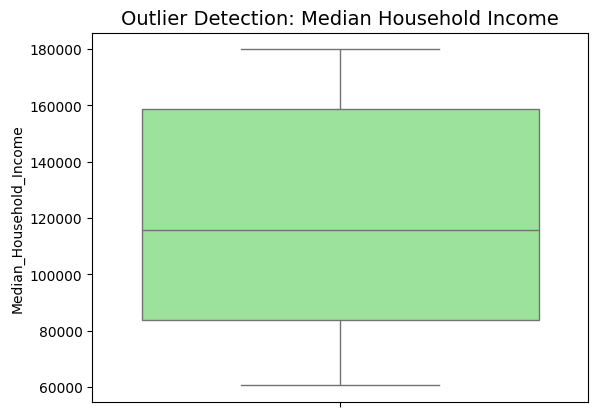

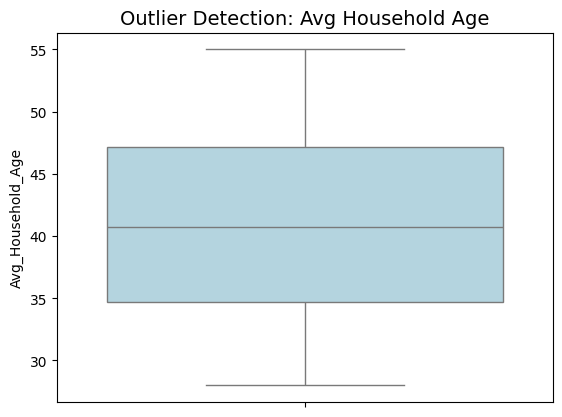

In [70]:
# Box Plot for Income
sns.boxplot(y=demographic_df['Median_Household_Income'], color='lightgreen')
plt.title('Outlier Detection: Median Household Income', fontsize=14)
plt.show()
plt.close()

# Box Plot for Age
sns.boxplot(y=demographic_df['Avg_Household_Age'], color='lightblue')
plt.title('Outlier Detection: Avg Household Age', fontsize=14)
plt.show()
plt.close()

No outliers seen in the data the dist

## Feature Engineering

Creating a Demand Index. AADT is the primary volume driver. More cars = more potential customers. Commercial Activity Score is a multiplier beacuse a car wash at a busy intersection near a Costco or Home Depot is worth more than one on a lonely commuter highway. All is divided by distance to center as a geographic weight. Locations closer to the city core or dense hubs are prioritized. 

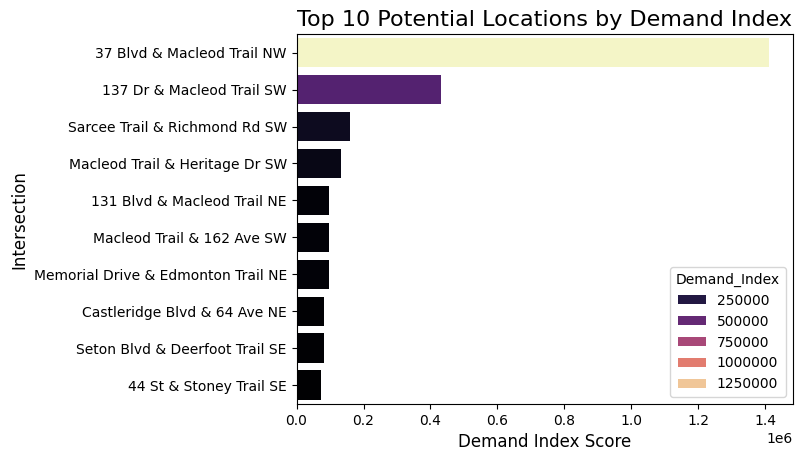

In [35]:
# Calculate Demand Index
#

demand_df['Demand_Index'] = (demand_df['AADT_Volume'] * demand_df['Commercial_Activity_Score']) / (demand_df['Distance_to_City_Center_km'] + 0.1)
demand_df_ranked = demand_df.sort_values(by='Demand_Index', ascending=False)

sns.barplot(data=demand_df_ranked.head(10), x='Demand_Index', y='Street_Intersection', hue='Demand_Index', palette='magma')
plt.title('Top 10 Potential Locations by Demand Index', fontsize=16)
plt.xlabel('Demand Index Score', fontsize=12)
plt.ylabel('Intersection', fontsize=12)
plt.show()
plt.close()

In [43]:
val_37 = demand_df.loc[demand_df['Street_Intersection'] == '37 Blvd & Macleod Trail NW', 'Distance_to_City_Center_km'].values[0]
val_137 = demand_df.loc[demand_df['Street_Intersection'] == '137 Dr & Macleod Trail SW', 'Distance_to_City_Center_km'].values[0]
print(f"37 Blvd = {val_37}")
print(f"137 Blvd = {val_137}")

37 Blvd = 0.75
137 Blvd = 1.74


Ignore the "37 Blvd & Macleod Trail NW" as it is at city center. The next top 3 locations are all in the Southwest quadrant.

---------------------------------------------------------------------------------------

Next, I have have both Demand dataset and Competition dataset i can look at every point in the demand dataset and see the distance it is to the closest point to a competitor in teh competition dataset.

Locations with high traffic AND a large distance to the nearest competitor are locations with the greatest potiential.

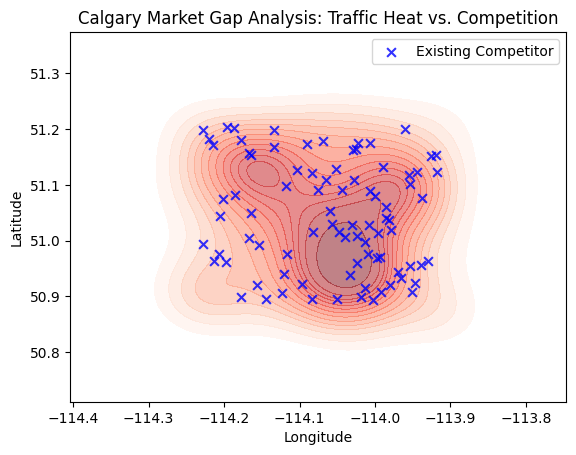

In [54]:
def haversine(lat1, lon1, lat2, lon2):
    """Calculates the distance in km between two lat/lon points."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a)) 
    return c * 6371 

min_distances = []
comp_counts_5km = []

for idx, demand_row in demand_df.iterrows():
    # Calculate distance from this intersection to ALL competitors
    distances = competition_df.apply(lambda comp_row: haversine(
        demand_row['Latitude'], 
        demand_row['Longitude'],
        comp_row['Latitude'], 
        comp_row['Longitude']
    ), axis=1)
    
    min_distances.append(distances.min())
    comp_counts_5km.append((distances <= 5.0).sum())

demand_df['Dist_to_Nearest_Comp_km'] = min_distances
demand_df['Comp_Density_5km'] = comp_counts_5km

# Visualization: Dual-Layer Market Gap Analysis

# Red Heat: Traffic Volume (AADT)
sns.kdeplot(
    x=demand_df['Longitude'], y=demand_df['Latitude'], 
    weights=demand_df['AADT_Volume'],
    fill=True, cmap='Reds', alpha=0.5, levels=15, thresh=0.1
)

# Blue Markers: Competitor Locations
plt.scatter(
    competition_df['Longitude'], competition_df['Latitude'], 
    color='blue', marker='x', s=40, label='Existing Competitor', alpha=0.8
)

plt.title('Calgary Market Gap Analysis: Traffic Heat vs. Competition')
plt.legend(loc='upper right')
plt.show()
plt.close()

Red Zones with no Blue 'X's are the primary candidates. They represent high traffic regions that are underserved by the competition. 

Red Zones with Blue 'X' mean that the there is high volumne however there is already sufficent competition present to mark that location as not profitable.

To find a list of top locations with high traffic AND a large distance to the nearest competitor (gold mines) we need to create a score that combines AADT_Volume and Dist_to_Nearest_Comp_km. This tells us which locations will be most profitable.

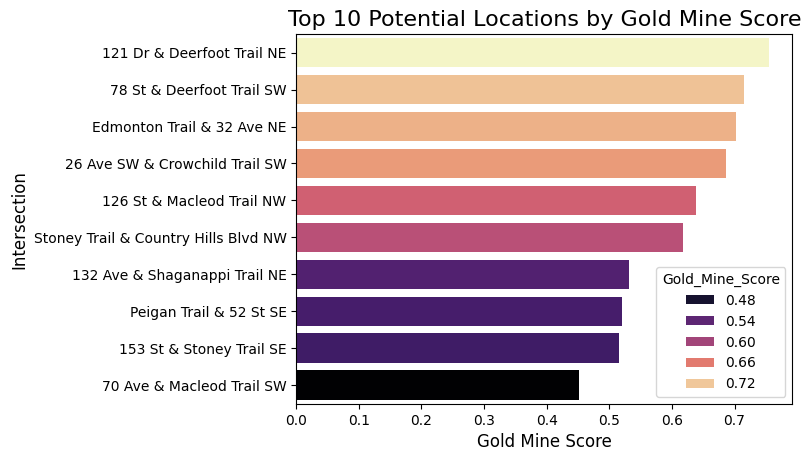

In [61]:
# Use MinMaxScaler to normalize both Traffic and Distance to range from 0 to 1
scaler = MinMaxScaler()
demand_df[['norm_AADT', 'norm_Dist']] = scaler.fit_transform(
    demand_df[['AADT_Volume', 'Dist_to_Nearest_Comp_km']])

# Multiply them: a high score requires BOTH high traffic and high isolation
demand_df['Gold_Mine_Score'] = demand_df['norm_AADT'] * demand_df['norm_Dist']

# Sort and identify the top locations
df_gold_mines = demand_df.sort_values(by='Gold_Mine_Score', ascending=False)
df_gold_mines[['Street_Intersection', 'AADT_Volume', 'Dist_to_Nearest_Comp_km', 'Gold_Mine_Score']].head(10)

# Visualize
sns.barplot(data=df_gold_mines.head(10), x='Gold_Mine_Score', y='Street_Intersection', hue='Gold_Mine_Score', palette='magma')
plt.title('Top 10 Potential Locations by Gold Mine Score', fontsize=16)
plt.xlabel('Gold Mine Score', fontsize=12)
plt.ylabel('Intersection', fontsize=12)
plt.show()
plt.close()

Concentrating on the top 4 show locations in the Southwest and Northeast that have the highest Gold Mine score. Also from the demand index we noticed that the top 4 were locations in the Southwest region. However the high demand Southwest locations did not appear in the Gold Mine locations, so we dont have a nice overlap.

--------------------------------------------------------------------------------------------------------------------------------

Next I want to target locations with High Traffic and High Earners and Low Competition. Combining demand, demographic and competition data.

In [86]:
# Create a list to store the closest community data
#

closest_community_data = []

for idx, demand_row in demand_df.iterrows():
    # Calculate distance to ALL communities in the demographic dataset
    distances = demographic_df.apply(lambda demo_row: haversine(
        demand_row['Latitude'], demand_row['Longitude'],
        demo_row['Latitude'], demo_row['Longitude']
    ), axis=1)
    
    # Find the index of the closest community
    closest_idx = distances.idxmin()
    
    # Select the demographic columns we want to bring over
    community_info = demographic_df.loc[closest_idx, [
        'Community_Name', 'Median_Household_Income', 'Avg_Household_Age', 
        'Pct_Apartment_Dwellers', 'Population_Density', 'Avg_Cars_Per_Household'
    ]]
    
    closest_community_data.append(community_info)

# Convert list to DataFrame and join with demand_df
community_features = pd.DataFrame(closest_community_data).reset_index(drop=True)
final_master_df = pd.concat([demand_df, community_features], axis=1)

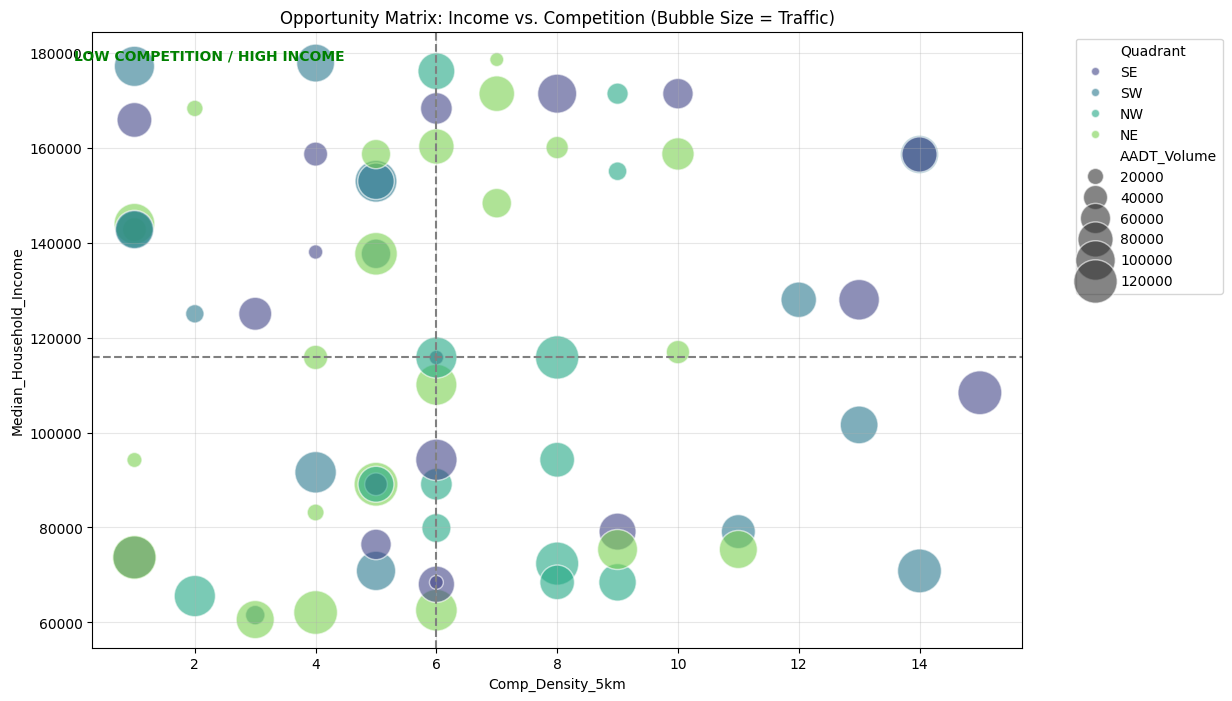

In [79]:

sns.scatterplot(
    data=final_master_df,
    x='Comp_Density_5km', 
    y='Median_Household_Income',
    size='AADT_Volume', 
    hue='Quadrant',
    sizes=(100, 1000), 
    alpha=0.6,
    palette='viridis'
)

# Label the "Gold Mine" quadrant
plt.axhline(final_master_df['Median_Household_Income'].median(), color='gray', linestyle='--')
plt.axvline(final_master_df['Comp_Density_5km'].median(), color='gray', linestyle='--')
plt.text(0, final_master_df['Median_Household_Income'].max(), "LOW COMPETITION / HIGH INCOME", color='green', fontweight='bold')

plt.title('Opportunity Matrix: Income vs. Competition (Bubble Size = Traffic)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()
plt.close()

I want to focus on the top left of the quadrant. This section includes areas with high income earners where compition is low. Circles that are larger are areas where traffic is higher. Should ignore the right quadrants as there is greater compition in those locations. Focusing on the top left will provide greater opporutnities. 

## Modeling

## Results

## Conclusion

## Next Steps